Step 1: Imports & Data Loading

In [26]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


df = pd.read_csv('diet_plan_ml_dataset.csv')

print("Data Loaded Successfully.")
print(f"Dataset Shape: {df.shape}")

Data Loaded Successfully.
Dataset Shape: (1000, 16)


Step 2: Preprocessing & Feature Engineering

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('diet_plan_ml_dataset.csv')

print("Columns in the loaded DataFrame:", df.columns.tolist())

le_gender = LabelEncoder()
le_stage = LabelEncoder()
if 'gender' in df.columns:
    df['gender_encoded'] = le_gender.fit_transform(df['gender'])
else:
    print("Error: 'gender' column not found. Please ensure your dataset is correct.")

if 'stage' in df.columns:
    df['stage_encoded'] = le_stage.fit_transform(df['stage'])
else:
    print("Error: 'stage' column not found. Please ensure your dataset is correct.")

feature_cols = [
    'age', 'gender_encoded', 'BMI', 'daily_steps',
    'sleep_hours', 'exercise_minutes', 'routine_adherence_score'
]
target_col = 'stage_encoded'
missing_features = [col for col in feature_cols if col not in df.columns]
if missing_features:
    print(f"Error: Missing expected feature columns: {missing_features}. Please check your dataset.")
    print("Available columns: ", df.columns.tolist())
else:
    X = df[feature_cols]
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Preprocessing Complete.")
    print("Features used for training:", X.columns.tolist())


Columns in the loaded DataFrame: ['age', 'gender', 'height_cm', 'weight_kg', 'BMI', 'daily_steps', 'sleep_hours', 'exercise_minutes', 'daily_calories', 'protein_g', 'carbs_g', 'fat_g', 'blood_pressure_sys', 'blood_glucose', 'routine_adherence_score', 'stage']
Preprocessing Complete.
Features used for training: ['age', 'gender_encoded', 'BMI', 'daily_steps', 'sleep_hours', 'exercise_minutes', 'routine_adherence_score']


Step 3: SVM Model

SVM Test Accuracy: 0.8900
SVM Log Loss: 0.2130


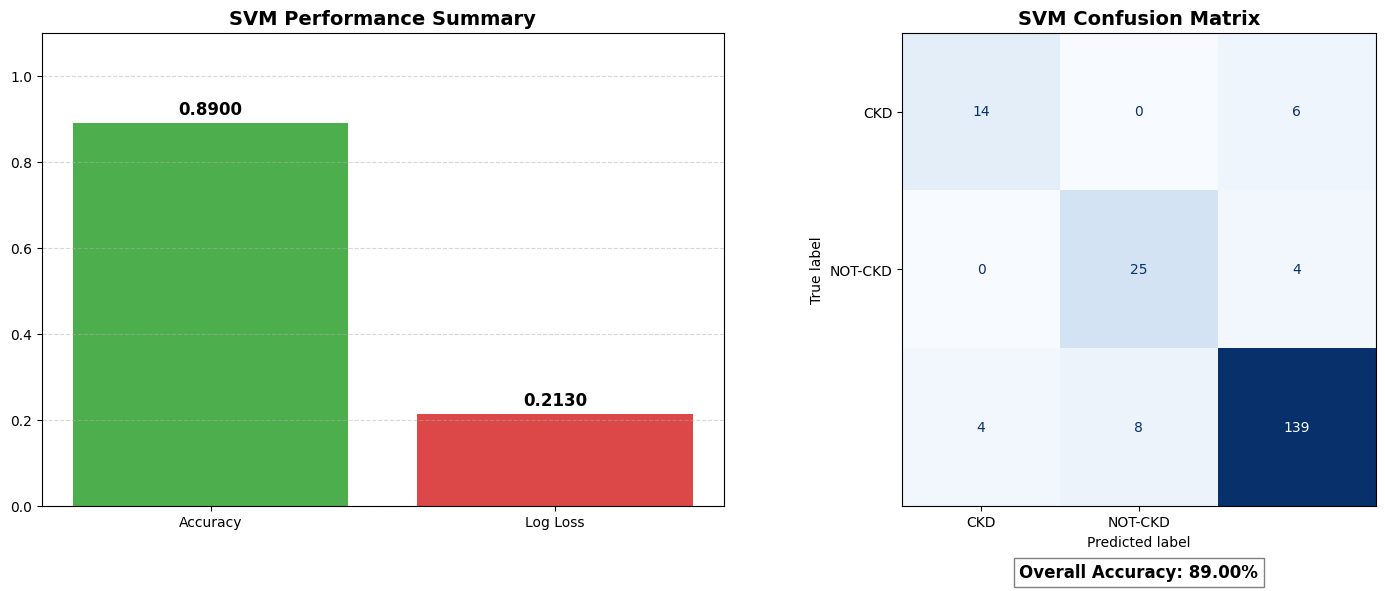

In [35]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_loss = log_loss(y_test, y_prob_svm)

print(f"SVM Test Accuracy: {svm_acc:.4f}")
print(f"SVM Log Loss: {svm_loss:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
metrics = ['Accuracy', 'Log Loss']
values = [svm_acc, svm_loss]
ax1.bar(metrics, values, color=['#2ca02c', '#d62728'], alpha=0.85)
ax1.set_ylim(0, 1.1)
ax1.set_title('SVM Performance Summary', fontsize=14, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(values):
    ax1.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=12)
cm = confusion_matrix(y_test, y_pred_svm)
labels = ['CKD', 'NOT-CKD']


disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax2, cmap='Blues', colorbar=False, values_format='d')

ax2.set_xticks(np.arange(len(labels)))
ax2.set_yticks(np.arange(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_yticklabels(labels)

ax2.set_title('SVM Confusion Matrix', fontsize=14, fontweight='bold')
ax2.text(0.5, -0.15, f"Overall Accuracy: {svm_acc*100:.2f}%",
         transform=ax2.transAxes, ha='center', fontsize=12,
         fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

Step 4 : KNN Model

KNN Test Accuracy: 0.8600
KNN Log Loss: 0.7996


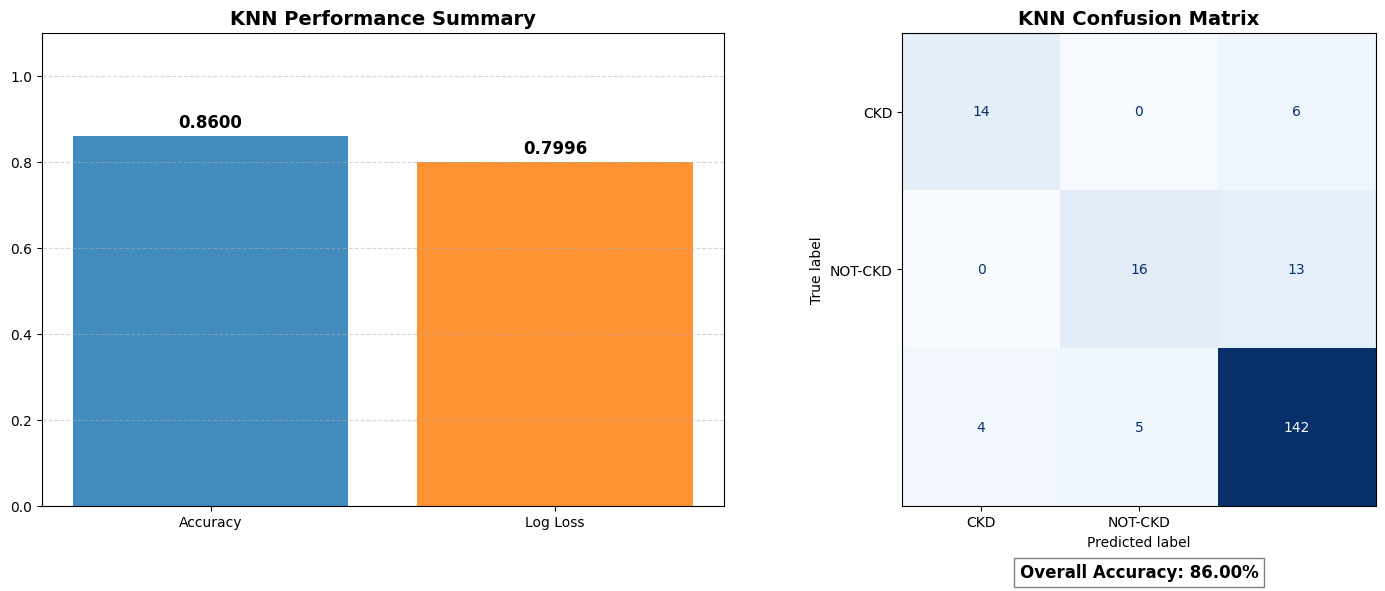

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)


y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)

knn_acc = accuracy_score(y_test, y_pred_knn)
knn_loss = log_loss(y_test, y_prob_knn)

print(f"KNN Test Accuracy: {knn_acc:.4f}")
print(f"KNN Log Loss: {knn_loss:.4f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

metrics = ['Accuracy', 'Log Loss']
values = [knn_acc, knn_loss]
ax1.bar(metrics, values, color=['#1f77b4', '#ff7f0e'], alpha=0.85)
ax1.set_ylim(0, 1.1)
ax1.set_title('KNN Performance Summary', fontsize=14, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(values):
    ax1.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=12)
cm = confusion_matrix(y_test, y_pred_knn)
labels = ['CKD', 'NOT-CKD']

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax2, cmap='Blues', colorbar=False, values_format='d')
ax2.set_xticks(np.arange(len(labels)))
ax2.set_yticks(np.arange(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_yticklabels(labels)

ax2.set_title('KNN Confusion Matrix', fontsize=14, fontweight='bold')
ax2.text(0.5, -0.15, f"Overall Accuracy: {knn_acc*100:.2f}%",
         transform=ax2.transAxes, ha='center', fontsize=12,
         fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

Step 5: Testing the System

In [48]:
import pandas as pd
import numpy as np

class DietPlanSystem:
    def __init__(self, model, scaler, gender_encoder):
        self.model = model
        self.scaler = scaler
        self.gender_encoder = gender_encoder

        self.stage_mapping = {0: 'Beginner', 1: 'Intermediate', 2: 'Advanced'}

    def predict_stage(self, user_data):
        height_m = user_data['height_cm'] / 100
        bmi_value = user_data['weight_kg'] / (height_m ** 2)
        gender_code = self.gender_encoder.transform([user_data['gender']])[0]

        features_df = pd.DataFrame([{
            'age': user_data['age'],
            'gender_encoded': gender_code,
            'BMI': bmi_value,
            'daily_steps': user_data['daily_steps'],
            'sleep_hours': user_data['sleep_hours'],
            'exercise_minutes': user_data['exercise_minutes'],
            'routine_adherence_score': user_data['routine_adherence_score']
        }])


        column_order = ['age', 'gender_encoded', 'BMI', 'daily_steps',
                        'sleep_hours', 'exercise_minutes', 'routine_adherence_score']
        features_df = features_df[column_order]

        features_scaled = self.scaler.transform(features_df)
        prediction = self.model.predict(features_scaled)[0]

        stage_name = self.stage_mapping.get(prediction, 'Beginner')
        return stage_name, bmi_value

    def generate_diet_plan(self, user_data, stage, goal='maintain'):

        if user_data['gender'] == 'Male':
            bmr = 10 * user_data['weight_kg'] + 6.25 * user_data['height_cm'] - 5 * user_data['age'] + 5
        else:
            bmr = 10 * user_data['weight_kg'] + 6.25 * user_data['height_cm'] - 5 * user_data['age'] - 161

        activity_multipliers = {'Beginner': 1.2, 'Intermediate': 1.55, 'Advanced': 1.725}
        tdee = bmr * activity_multipliers.get(stage, 1.2)

        if goal == 'weight_loss': target_calories = tdee - 500
        elif goal == 'muscle_gain': target_calories = tdee + 300
        else: target_calories = tdee

        if stage == 'Advanced': macros = {'protein': 0.35, 'fat': 0.25, 'carbs': 0.40}
        elif stage == 'Intermediate': macros = {'protein': 0.30, 'fat': 0.30, 'carbs': 0.40}
        else: macros = {'protein': 0.25, 'fat': 0.30, 'carbs': 0.45}

        return {
            'Daily_Calories': int(target_calories),
            'Protein_g': int((target_calories * macros['protein']) / 4),
            'Fat_g': int((target_calories * macros['fat']) / 9),
            'Carbs_g': int((target_calories * macros['carbs']) / 4)
        }

app = DietPlanSystem(model, scaler, le_gender)

new_user = {
    'age': 30,
    'gender': 'Male',
    'height_cm': 175,
    'weight_kg': 85,
    'daily_steps': 6000,
    'sleep_hours': 7,
    'exercise_minutes': 45,
    'routine_adherence_score': 0.55
}

predicted_stage, bmi = app.predict_stage(new_user)
diet_plan = app.generate_diet_plan(new_user, predicted_stage, goal='weight_loss')

print("\n" + "="*40)
print(f"Analysis: BMI {bmi:.2f} | Predicted Level: {predicted_stage.upper()}")
print(f"Daily Calories: {diet_plan['Daily_Calories']} kcal")
print(f"Macros: P:{diet_plan['Protein_g']}g, C:{diet_plan['Carbs_g']}g, F:{diet_plan['Fat_g']}g")
print("="*40)


Analysis: BMI 27.76 | Predicted Level: ADVANCED
Daily Calories: 2602 kcal
Macros: P:227g, C:260g, F:72g


In [49]:
import numpy as np

class DietPlanSystem:
    def __init__(self, model, scaler, gender_encoder):
        self.model = model
        self.scaler = scaler
        self.gender_encoder = gender_encoder

    def predict_stage(self, user_data):
        """Predicts the user's fitness stage based on input data."""
        height_m = user_data['height_cm'] / 100
        bmi = user_data['weight_kg'] / (height_m ** 2)

        # Gender encoding based on your Step 2 logic
        # le_gender expects an iterable, so wrap user_data['gender'] in a list
        gender_code = self.gender_encoder.transform([user_data['gender']])[0]

        # Feature columns defined in your preprocessing (from cell YQwjQGNJMRLv)
        features = np.array([[
            user_data['age'], gender_code, bmi, user_data['daily_steps'],
            user_data['sleep_hours'], user_data['exercise_minutes'],
            user_data['routine_adherence_score']
        ]])

        features_scaled = self.scaler.transform(features)
        stage = self.model.predict(features_scaled)[0]
        # Decode the numerical stage back to a meaningful label if necessary
        # (Assuming le_stage is available globally or passed here if needed)
        # For now, let's assume the predicted numerical stage is directly usable or will be handled downstream
        return stage, bmi

    def generate_diet_plan(self, user_data, stage, goal='maintain'):
        """Generates calorie and macro targets based on BMR + Predicted Stage."""
        # BMR Calculation (Mifflin-St Jeor)
        if user_data['gender'] == 'Male':
            bmr = 10 * user_data['weight_kg'] + 6.25 * user_data['height_cm'] - 5 * user_data['age'] + 5
        else:
            bmr = 10 * user_data['weight_kg'] + 6.25 * user_data['height_cm'] - 5 * user_data['age'] - 161


        stage_label_map = {0: 'Beginner', 1: 'Intermediate', 2: 'Advanced'}
        stage_name = stage_label_map.get(stage, 'Beginner') # Default to Beginner if stage is not in map

        activity_multipliers = {
            'Beginner': 1.2,
            'Intermediate': 1.55,
            'Advanced': 1.725
        }
        tdee = bmr * activity_multipliers.get(stage_name, 1.2)

        # Goal adjustments
        if goal == 'weight_loss':
            target_calories = tdee - 500
        elif goal == 'muscle_gain':
            target_calories = tdee + 300
        else:
            target_calories = tdee

        # Macro splits based on fitness stage
        if stage_name == 'Advanced':
            macros = {'protein': 0.35, 'fat': 0.25, 'carbs': 0.40}
        elif stage_name == 'Intermediate':
            macros = {'protein': 0.30, 'fat': 0.30, 'carbs': 0.40}
        else: # Beginner or unknown
            macros = {'protein': 0.25, 'fat': 0.30, 'carbs': 0.45}

        return {
            'Predicted_Stage': stage_name,
            'Daily_Calories': int(target_calories),
            'Protein_g': int((target_calories * macros['protein']) / 4),
            'Fat_g': int((target_calories * macros['fat']) / 9),
            'Carbs_g': int((target_calories * macros['carbs']) / 4)
        }

In [50]:

import joblib
joblib.dump(model, 'diet_model.pkl')

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_gender, 'gender_encoder.pkl')

print("Files saved successfully: diet_model.pkl, scaler.pkl, gender_encoder.pkl")

Files saved successfully: diet_model.pkl, scaler.pkl, gender_encoder.pkl
